# Notebook 03 — Feature Engineering
## ML-based Predictive Maintenance for Rural Borehole Water Pumps in Northern Nigeria
**Course:** COEN807 — Machine Learning | **Institution:** ABU Zaria  
**Report Section Produced:** — Feature Engineering  

---
### Pipeline Summary
| Step | Operation | Input → Output |
|---|---|---|
| 1 | Rolling statistics (mean, std, max × 2 windows) | 50 → 300 rolling features |
| 2 | Rate-of-change (first-order diff) | 50 → 50 diff features |
| 3 | Combine all features | 50 raw + 300 rolling + 50 diff = **400 total** |
| 4 | StandardScaler (fit on train only) | 400 scaled features |
| 5 | PCA — 95% variance retained | 400 → **101 components** |

### Figures Produced
| File | Caption |
|---|---|
| `08_feature_engineering.png` | Figure 8 — Feature type breakdown + sensor importance |
| `09_pca_variance.png` | Figure 9 — PCA scree plot + cumulative variance |
| `10_pca_scatter.png` | Figure 10 — 2D PCA projection: NORMAL vs FAULT |

## Cell 1 — Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import joblib, warnings, os, json, time
warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('outputs/figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


## Cell 2 — Load Preprocessed Data

In [34]:
X_train = pd.read_pickle('outputs/X_train_raw.pkl')
X_test  = pd.read_pickle('outputs/X_test_raw.pkl')
y_train = pd.read_pickle('outputs/y_train.pkl')
y_test  = pd.read_pickle('outputs/y_test.pkl')
sensor_cols = X_train.columns.tolist()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train FAULT% : {y_train.mean()*100:.1f}%')
print(f'y_test  FAULT% : {y_test.mean()*100:.1f}%')

X_train : (131040, 50)
X_test  : (89280, 50)
y_train FAULT% : 6.8%
y_test  FAULT% : 6.2%


## Cell 3 - Build Features
**Rolling windows:** 5 rows 5 min) and 15 rows (15 min) at 12-min sampling  
**Statistics:** mean, std, max — standard for pump condition monitoring (Lei et al., 2018)  
**Rate of change:** first-order diff detects rapid signal shifts preceding failure  

Feature count: 50 raw + 300 rolling + 50 diff = **400 features total**

In [35]:
def build_features(X, windows=[5, 15]):
    """Build rolling and diff features. Pandas 3.x compatible."""
    t0 = time.time()
    parts = [X]
    for w in windows:
        r = X.rolling(window=w, min_periods=1)
        parts.append(r.mean().add_suffix(f'_mean{w}'))
        parts.append(r.std().fillna(0).add_suffix(f'_std{w}'))
        parts.append(r.max().add_suffix(f'_max{w}'))
    parts.append(X.diff().fillna(0).add_suffix('_diff'))
    feat = pd.concat(parts, axis=1).fillna(0)
    print(f'  {feat.shape[1]} features built in {time.time()-t0:.1f}s')
    return feat

print('Building TRAIN features...')
X_tr_feat = build_features(X_train)
print('Building TEST features...')
X_te_feat = build_features(X_test)

print(f'\nTrain: {X_tr_feat.shape}  |  Test: {X_te_feat.shape}')
print(f'Feature columns (first 5): {list(X_tr_feat.columns[:5])}')

Building TRAIN features...
  400 features built in 10.9s
Building TEST features...
  400 features built in 5.6s

Train: (131040, 400)  |  Test: (89280, 400)
Feature columns (first 5): ['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04']


## Cell 4 — StandardScaler
This Cell Fit the scaler exclusively on the training set.  
Applying training statistics to the test set to prevents data leakage.

In [36]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_feat)
X_te_sc = scaler.transform(X_te_feat)
joblib.dump(scaler, 'outputs/scaler.pkl')

print(f'Scaled train: {X_tr_sc.shape}')
print(f'Scaled test : {X_te_sc.shape}')
print(f'Scaler saved → outputs/scaler.pkl')

Scaled train: (131040, 400)
Scaled test : (89280, 400)
Scaler saved → outputs/scaler.pkl


## Cell 5 — PCA (95% Variance Threshold)
PCA addresses two issues in the engineered feature set:  
1. **Multicollinearity** — rolling stats from the same sensor are highly correlated  
2. **Dimensionality** — 400 features with SVM would be computationally expensive  

Fit on training data only; transform both sets.  
> Reference: Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis. *PTRS-A, 374*, 20150202. https://doi.org/10.1098/rsta.2015.0202

In [37]:
pca = PCA(n_components=0.95, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)
joblib.dump(pca, 'outputs/pca.pkl')

evr     = pca.explained_variance_ratio_
evr_cum = np.cumsum(evr)

print(f'Input features  : {X_tr_sc.shape[1]}')
print(f'PCA components  : {pca.n_components_}  (95% variance retained)')
print(f'Train PCA shape : {X_tr_pca.shape}')
print(f'Test  PCA shape : {X_te_pca.shape}')
print(f'Variance @ PC5  : {evr_cum[4]*100:.1f}%')
print(f'Variance @ PC10 : {evr_cum[9]*100:.1f}%')
print(f'Variance @ PC20 : {evr_cum[19]*100:.1f}%')

# Save for modelling notebooks
pd.DataFrame(X_tr_pca).to_pickle('outputs/X_train_pca.pkl')
pd.DataFrame(X_te_pca).to_pickle('outputs/X_test_pca.pkl')
X_tr_feat.to_pickle('outputs/X_train_feat.pkl')
X_te_feat.to_pickle('outputs/X_test_feat.pkl')
print('\nSaved: X_train_pca.pkl, X_test_pca.pkl, X_train_feat.pkl, X_test_feat.pkl')

Input features  : 400
PCA components  : 116  (95% variance retained)
Train PCA shape : (131040, 116)
Test  PCA shape : (89280, 116)
Variance @ PC5  : 49.4%
Variance @ PC10 : 58.9%
Variance @ PC20 : 68.8%

Saved: X_train_pca.pkl, X_test_pca.pkl, X_train_feat.pkl, X_test_feat.pkl


## Cell 6 — RF Feature Importance (Raw Sensors)

In [38]:
rf_raw = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf_raw.fit(X_tr_sc[:, :50], y_train)
fi = pd.Series(rf_raw.feature_importances_, index=sensor_cols).sort_values(ascending=False)
top5 = fi.head(5).index.tolist()
print(f'Top 5 most informative sensors: {top5}')
print()
print(fi.head(10).to_string())

Top 5 most informative sensors: ['sensor_10', 'sensor_04', 'sensor_11', 'sensor_12', 'sensor_13']

sensor_10    0.195663
sensor_04    0.151261
sensor_11    0.101178
sensor_12    0.099033
sensor_13    0.072193
sensor_49    0.061542
sensor_00    0.049609
sensor_07    0.047014
sensor_06    0.040854
sensor_48    0.032273


## Cell 7 — Figure 8: Feature Engineering Summary

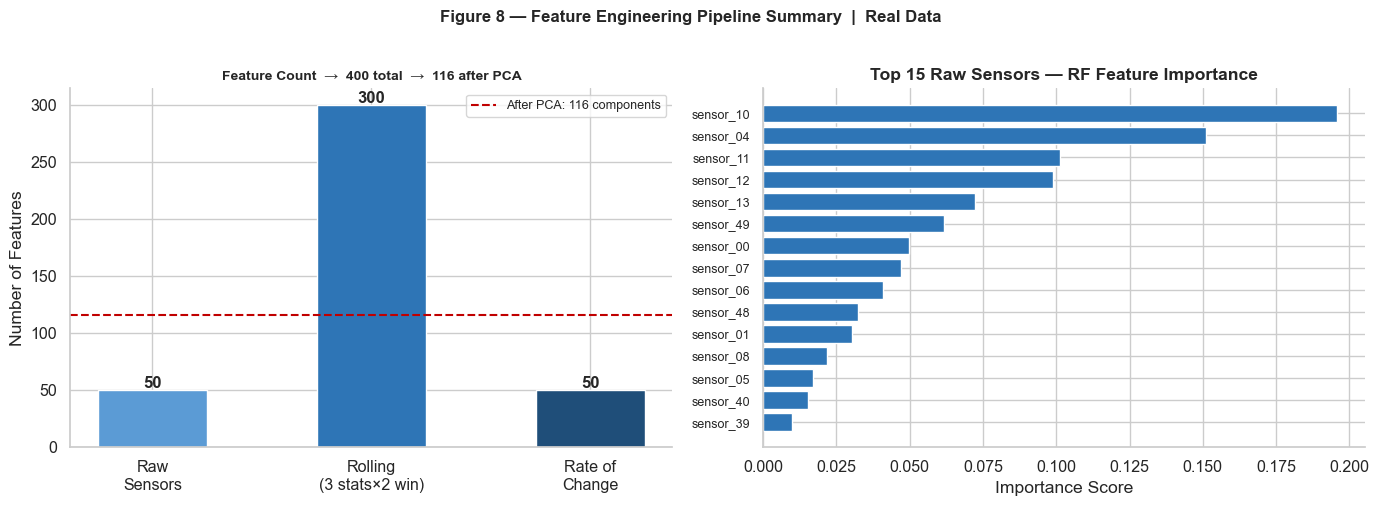

Figure 8 saved → outputs/figures/08_feature_engineering.png


In [39]:
n_raw=50; n_roll=50*3*2; n_diff=50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 8 — Feature Engineering Pipeline Summary  |  Real Data',
             fontsize=12, fontweight='bold', y=1.01)

labels = ['Raw\nSensors','Rolling\n(3 stats×2 win)','Rate of\nChange']
counts = [n_raw, n_roll, n_diff]
colors = ['#5B9BD5','#2E75B6','#1F4E79']
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar,val in zip(bars,counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{val}', ha='center', fontweight='bold', fontsize=12)
axes[0].axhline(pca.n_components_, color='#C00000', linestyle='--', lw=1.5,
                label=f'After PCA: {pca.n_components_} components')
axes[0].set_title(f'Feature Count  →  {n_raw+n_roll+n_diff} total  →  {pca.n_components_} after PCA',
                  fontweight='bold', fontsize=10)
axes[0].set_ylabel('Number of Features'); axes[0].legend(fontsize=9)

fi15 = fi.head(15)
axes[1].barh(range(15), fi15.values[::-1], color='#2E75B6', edgecolor='white')
axes[1].set_yticks(range(15)); axes[1].set_yticklabels(fi15.index[::-1], fontsize=9)
axes[1].set_title('Top 15 Raw Sensors — RF Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/figures/08_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved → outputs/figures/08_feature_engineering.png')

## Cell 8 — Figure 9: PCA Explained Variance

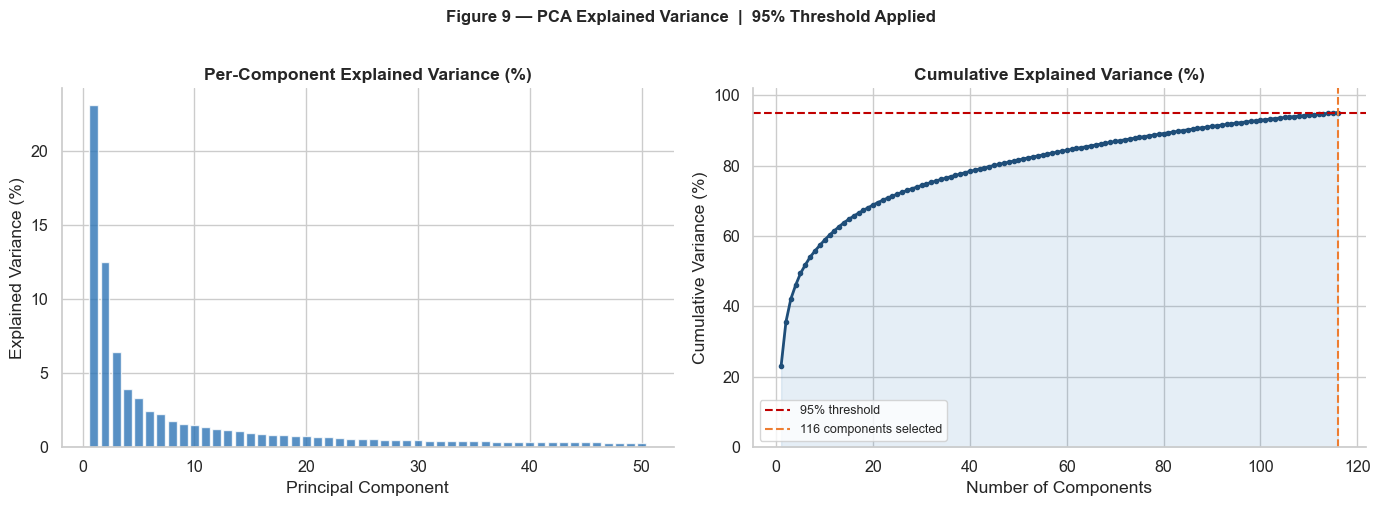

Figure 9 saved → outputs/figures/09_pca_variance.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 9 — PCA Explained Variance  |  95% Threshold Applied',
             fontsize=12, fontweight='bold', y=1.01)

n_show = min(50, len(evr))
axes[0].bar(range(1,n_show+1), evr[:n_show]*100, color='#2E75B6', alpha=0.8, edgecolor='white')
axes[0].set_title('Per-Component Explained Variance (%)', fontweight='bold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1,len(evr)+1), evr_cum*100, color='#1F4E79', lw=2, marker='o', markersize=3)
axes[1].axhline(95, color='#C00000', linestyle='--', lw=1.5, label='95% threshold')
axes[1].axvline(pca.n_components_, color='#ED7D31', linestyle='--', lw=1.5,
                label=f'{pca.n_components_} components selected')
axes[1].fill_between(range(1,pca.n_components_+1),
                      evr_cum[:pca.n_components_]*100, alpha=0.12, color='#2E75B6')
axes[1].set_title('Cumulative Explained Variance (%)', fontweight='bold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 102)
plt.tight_layout()
plt.savefig('outputs/figures/09_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved → outputs/figures/09_pca_variance.png')

## Cell 9 — Figure 10: PCA 2D Scatter

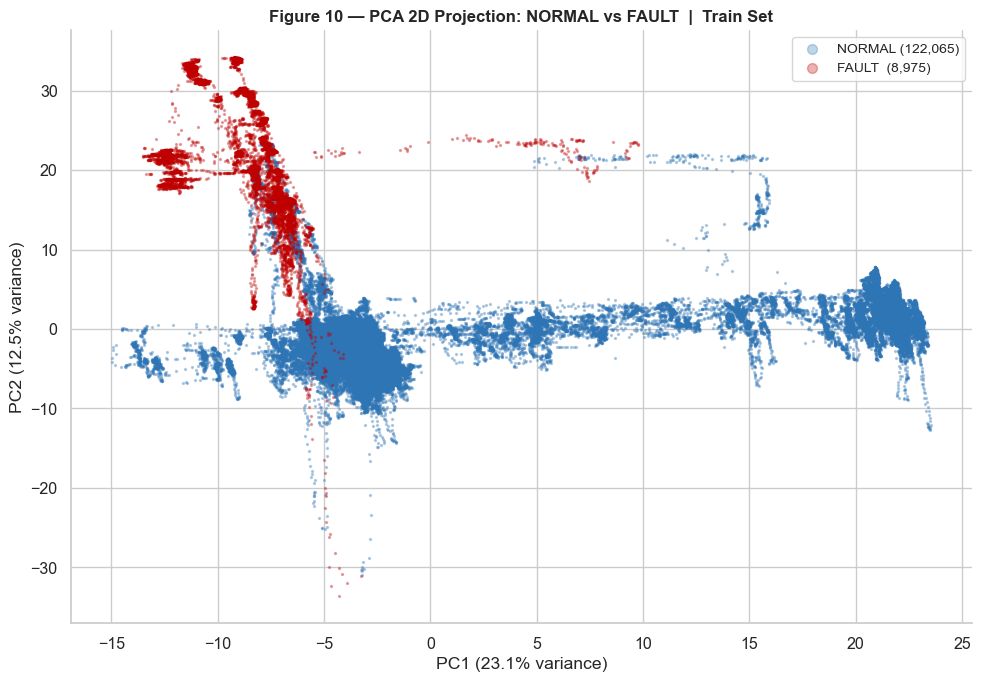

Figure 10 saved → outputs/figures/10_pca_scatter.png


In [41]:
y_arr = y_train.values
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_tr_pca[y_arr==0,0], X_tr_pca[y_arr==0,1],
           c='#2E75B6', s=2, alpha=0.3, label=f'NORMAL ({(y_arr==0).sum():,})')
ax.scatter(X_tr_pca[y_arr==1,0], X_tr_pca[y_arr==1,1],
           c='#C00000', s=2, alpha=0.3, label=f'FAULT  ({(y_arr==1).sum():,})')
ax.legend(fontsize=10, markerscale=5)
ax.set_title('Figure 10 — PCA 2D Projection: NORMAL vs FAULT  |  Train Set',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
plt.tight_layout()
plt.savefig('outputs/figures/10_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved → outputs/figures/10_pca_scatter.png')

## Cell 10 — Feature Engineering Summary

In [43]:
feat_info = {
    'n_raw':50,'n_rolling':300,'n_diff':50,
    'n_total_before_pca':400,
    'n_pca_components':int(pca.n_components_),
    'windows':[5,15],'stats':['mean','std','max'],
    'top5_sensors':top5
}
with open('outputs/feat_info.json','w') as f:
    json.dump(feat_info,f,indent=2)

print('='*60)
print('FEATURE ENGINEERING SUMMARY ')
print('='*60)
print(f'  Raw sensors             : 50')
print(f'  Rolling stats (3×2 win) : 300')
print(f'  Rate-of-change (diff)   : 50')
print(f'  Total before PCA        : 400')
print(f'  After PCA (95% var)     : {pca.n_components_} components')
print(f'  Top 5 sensors           : {top5}')
print('='*60)
print('  Files saved to outputs/:')
print('    X_train_pca.pkl, X_test_pca.pkl')
print('    X_train_feat.pkl, X_test_feat.pkl')
print('    scaler.pkl, pca.pkl, feat_info.json')
print('  NEXT: Notebook 04 — Model Training')

FEATURE ENGINEERING SUMMARY 
  Raw sensors             : 50
  Rolling stats (3×2 win) : 300
  Rate-of-change (diff)   : 50
  Total before PCA        : 400
  After PCA (95% var)     : 116 components
  Top 5 sensors           : ['sensor_10', 'sensor_04', 'sensor_11', 'sensor_12', 'sensor_13']
  Files saved to outputs/:
    X_train_pca.pkl, X_test_pca.pkl
    X_train_feat.pkl, X_test_feat.pkl
    scaler.pkl, pca.pkl, feat_info.json
  NEXT: Notebook 04 — Model Training
